# Start

In [ ]:
!pip install fastai==2.7.18

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [16]:
!git clone https://github.com/jollyoli93/jackoliver_24862664_dissertation.git

Cloning into 'jackoliver_24862664_dissertation'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 10 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (10/10), 17.75 MiB | 13.72 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [18]:
!cd jackoliver_24862664_dissertation

In [19]:
!unzip test.zip -d /content/
!unzip trainvalid.zip -d /content/

Archive:  test.zip
replace /content/test/skip-93.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/test/skip-93.jpg  
  inflating: /content/test/rebar-54.jpg  
  inflating: /content/test/formwork.jpg  
  inflating: /content/test/plant-6.jpg  
  inflating: /content/test/precast-1.jpg  
  inflating: /content/test/skip-10.jpg  
  inflating: /content/test/pipes-13.jpg  
  inflating: /content/test/rebar-71.jpg  
  inflating: /content/test/concrete-53.jpg  
  inflating: /content/test/plant-4.jpg  
  inflating: /content/test/skip-102.jpg  
  inflating: /content/test/precast.jpg  
  inflating: /content/test/concrete-56.jpg  
  inflating: /content/test/precast-16.jpg  
  inflating: /content/test/precast-14.jpg  
  inflating: /content/test/formwork-7.jpg  
  inflating: /content/test/plant-9.jpg  
  inflating: /content/test/concrete-3.jpg  
  inflating: /content/test/precast-11.jpg  
  inflating: /content/test/precast-8.jpg  
Archive:  trainvalid.zip
replace /content/trainvalid/p

## Class to Index Helpers

In [20]:
cls = ['precast', 'concrete', 'beams', 'formwork', 'rebar', 'skip', 'background', 'pipes', 'plant']


In [21]:

cls_index = {cls[i]:i for i in range(len(cls))}

In [22]:
# index_cls = {i:cls_names[i] for i in range(len(cls_names))}
cls_index = {cls[i]:i for i in range(len(cls))}
cls_names = {v: k for k, v in cls_index.items()}

In [23]:

cls_index, cls_names

({'precast': 0,
  'concrete': 1,
  'beams': 2,
  'formwork': 3,
  'rebar': 4,
  'skip': 5,
  'background': 6,
  'pipes': 7,
  'plant': 8},
 {0: 'precast',
  1: 'concrete',
  2: 'beams',
  3: 'formwork',
  4: 'rebar',
  5: 'skip',
  6: 'background',
  7: 'pipes',
  8: 'plant'})

## Image Statistics

In [27]:
from pathlib import Path
from PIL import Image

image_dir = Path('/content/trainvalid')

rows = []
for image_file in image_dir.glob("*.jpg"):
    file_name = image_file.stem.rsplit("/", 1)[0]
    cls = file_name.split("-")[0]

    with Image.open(image_file) as img:
      size = img.size[0]
    rows.append({"Filename":file_name, "Class": cls, "Size": size})


In [28]:
import pandas as pd

image_df = pd.DataFrame(rows); image_df

,Filename,Class,Size
0,formwork-63,formwork,315
1,background-33,background,189
2,concrete-40,concrete,397
3,formwork-67,formwork,220
4,skip-88,skip,612
...,...,...,...
467,skip-78,skip,700
468,skip-92,skip,406
469,background-30,background,371
470,concrete-49,concrete,119


In [29]:
image_df.describe(); image_df.Class.describe()

,Class
count,472
unique,9
top,precast
freq,64


In [30]:
image_df.Size.describe()

,Size
count,472.000000
mean,444.817797
std,259.142766
min,65.000000
25%,258.250000
50%,393.500000
75%,620.750000
max,2274.000000


<Axes: >

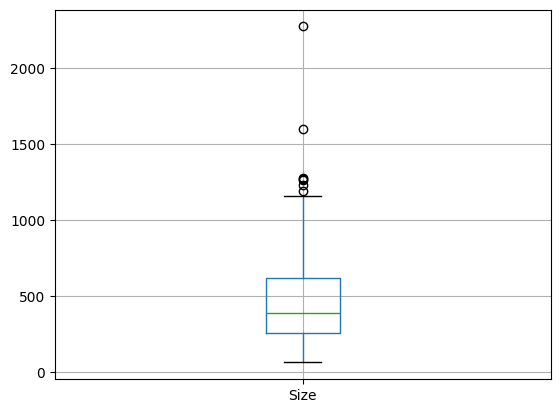

In [31]:
image_df.boxplot()

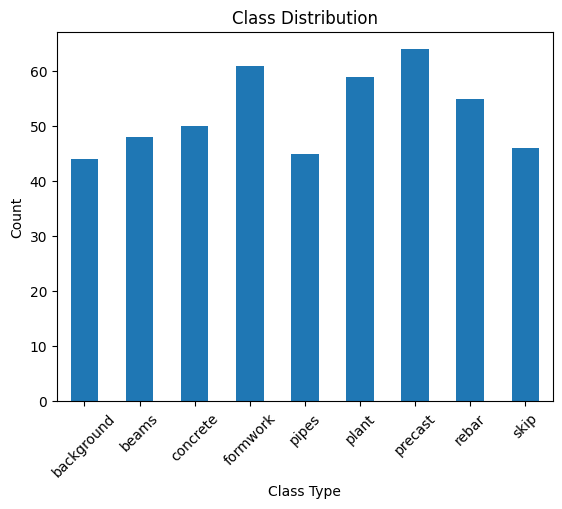

In [32]:
cls_df = image_df.Class.value_counts().sort_index().plot.bar()

cls_df.set_title("Class Distribution")
cls_df.set_xlabel("Class Type")
cls_df.set_ylabel("Count")

cls_df.tick_params(axis='x', rotation=45)

## Create Dataset

In [33]:
from fastai.data.all import *
from fastai.vision.all import *

In [34]:
def get_labels(image_file):
  file_name = image_file.stem.rsplit("/", 1)
  cls = str(file_name[0].split("-")[0])
  return cls

In [35]:
get_labels(image_dir)

'trainvalid'

# Base Model

In [36]:
# dblock = DataBlock(
#     blocks = (ImageBlock, CategoryBlock),
#     get_items=get_image_files,
#     get_y = get_labels,
#     # get_y=RegexLabeller(pat=r'([^/]+)(?=-\d+)'),
#     splitter = RandomSplitter(),
#     item_tfms= Resize(224)
#     )

In [37]:
items = get_image_files(image_dir)
labels = [get_labels(o) for o in items]

In [38]:
from fastai.data.transforms import IndexSplitter
from sklearn.model_selection import train_test_split

train_idx, valid_idx = train_test_split(
    range(len(items)),
    test_size=0.2,
    random_state=42,
    stratify=labels
)


In [39]:
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    get_y=get_labels,
    splitter=IndexSplitter(valid_idx),
    item_tfms=Resize(224)
)

In [40]:
dls = dblock.dataloaders(image_dir)

In [42]:
dset = dblock.datasets('/content/trainvalid')

In [43]:
dset.train[0]

(PILImage mode=RGB size=315x338, TensorCategory(3))

In [44]:
dset.vocab

['background', 'beams', 'concrete', 'formwork', 'pipes', 'plant', 'precast', 'rebar', 'skip']

In [45]:
len(dset.train)

393

In [46]:
len(dset.valid)

99

## Plot Train/Test split

In [47]:
from collections import Counter

train_labels = [dls.vocab[y] for _, y in dls.train_ds]
valid_labels = [dls.vocab[y] for _, y in dls.valid_ds]

print("Train")
print(Counter(train_labels))

print("\nValid")
print(Counter(valid_labels))

Train
Counter({'precast': 56, 'formwork': 50, 'plant': 50, 'rebar': 46, 'concrete': 42, 'skip': 39, 'beams': 38, 'pipes': 37, 'background': 35})

Valid
Counter({'precast': 14, 'formwork': 13, 'plant': 12, 'rebar': 11, 'concrete': 11, 'beams': 10, 'skip': 10, 'pipes': 9, 'background': 9})


In [48]:
test_files = get_image_files('/content/test')
test_class_count = Counter(f.stem.split('-')[0] for f in test_files)

In [49]:
pd.Series(test_class_count)

,0
plant,6
precast,12
concrete,6
formwork,4
pipes,2
skip,6
rebar,4


In [50]:
import pandas as pd

train_counts = pd.Series(train_labels).value_counts()
valid_counts = pd.Series(valid_labels).value_counts()
test_counts = pd.Series(test_class_count)

dist_df = pd.DataFrame({
    'train': train_counts,
    'valid': valid_counts,
    'test' : test_counts
}).fillna(0).astype(int)

dist_df['train_%'] = (dist_df['train'] / dist_df['train'].sum() * 100).round(1)
dist_df['valid_%'] = (dist_df['valid'] / dist_df['valid'].sum() * 100).round(1)

print(dist_df.sort_index())

            train  valid  test  train_%  valid_%
background     35      9     0      8.9      9.1
beams          38     10     0      9.7     10.1
concrete       42     11     6     10.7     11.1
formwork       50     13     4     12.7     13.1
pipes          37      9     2      9.4      9.1
plant          50     12     6     12.7     12.1
precast        56     14    12     14.2     14.1
rebar          46     11     4     11.7     11.1
skip           39     10     6      9.9     10.1


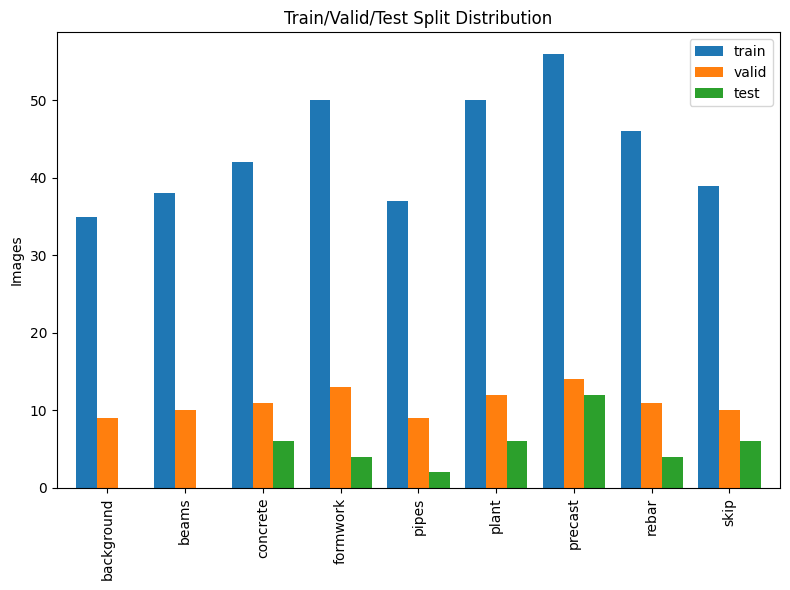

In [51]:
dist_df[['train', 'valid', 'test']].plot(
    kind='bar',
    figsize=(8, 6),
    width=0.8
)
plt.title("Train/Valid/Test Split Distribution")
plt.ylabel('Images')
plt.tight_layout()
plt.show()

In [52]:
path = '/content/drive/MyDrive/Crane-Detector/Image_Classes/Images/trainvalid'

In [53]:
set_seed(42)

In [54]:
dls = dblock.dataloaders(path)

TypeError: 'NoneType' object is not iterable

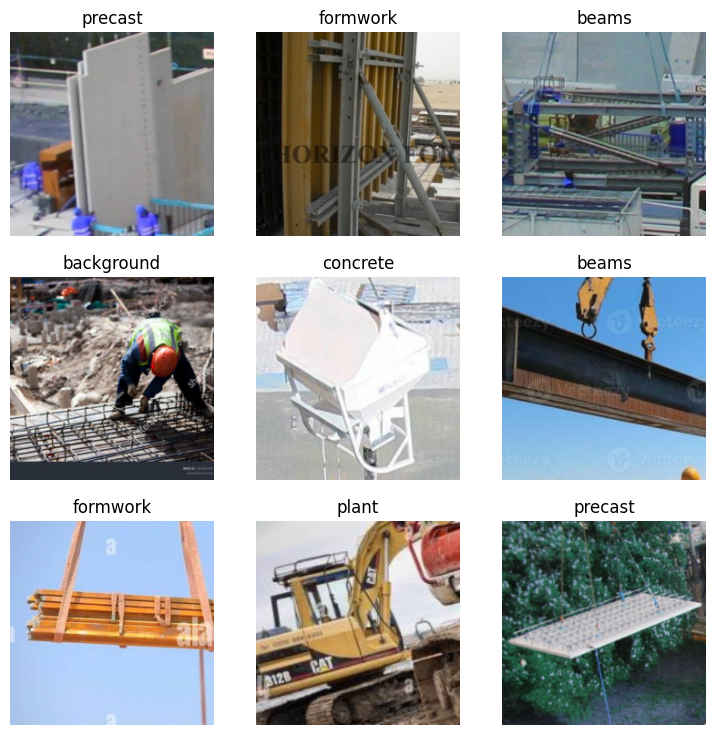

In [55]:
dls.show_batch()

## Define base model

In [56]:
learn = vision_learner(
    dls,
    resnet18,
    metrics=accuracy
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 38.1MB/s]


In [ ]:
learn.lr_find(suggest_funcs=(valley, slide))

<div><div><progress max="17" value="0"></progress> 0.00% [0/17 00:00&lt;?]</div><div></div><div><progress max="6" value="0"></progress> 0.00% [0/6 00:00&lt;?]</div></div>

In [ ]:
learn.fine_tune(5, 0.001)

In [ ]:
base2 = vision_learner(
    dls,
    resnet18,
    metrics=accuracy
)
base2.fine_tune(5, 0.001)

In [ ]:
base3 = vision_learner(
    dls,
    resnet18,
    metrics=accuracy
)
base3.fine_tune(5, 0.001)

In [ ]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(7,7), dpi=100)

In [ ]:
interp.most_confused(min_val=2)

# EXP 2 - Transforms

In [ ]:
def train(
    arch, item=None, batch=None, epochs=5, b_size=32, lr=0.001, fine_tune=True, no_runs=3, show_cm=True):

    results = []
    best_acc = 0
    best_learn = None

    for run in range(no_runs):

        print(f"\nRun {run+1}/{no_runs}")

        dblock = DataBlock(
            blocks=(ImageBlock, CategoryBlock),
            get_items=get_image_files,
            get_y=get_labels,
            splitter=RandomSplitter(valid_pct=0.2, seed=42),
            item_tfms=item,
            batch_tfms=batch
        )

        dls = dblock.dataloaders(path, bs=b_size)

        learn = vision_learner(
            dls,
            arch,
            metrics=accuracy
        )

        if fine_tune:
            learn.fine_tune(epochs, lr)
        else:
            learn.fit_one_cycle(epochs, lr)

        acc = learn.recorder.values[-1][2]
        results.append(acc)

        print(f"Accuracy: {acc:.4f}")

        if acc > best_acc:
            best_acc = acc
            best_learn = learn

    mean_acc = np.mean(results)
    std_acc = np.std(results)

    print("\n========================")
    print(f"Mean Accuracy : {mean_acc:.4f}")
    print(f"Std Accuracy  : {std_acc:.4f}")
    print(f"Best Accuracy : {best_acc:.4f}")
    print("========================")

    if show_cm and best_learn is not None:
        interp = ClassificationInterpretation.from_learner(best_learn)
        interp.plot_confusion_matrix(figsize=(7,7), dpi=60)

        print("\nMost confused classes:")
        print(interp.most_confused(min_val=2))

    return best_learn, results

## Presize at 460 (> Mean) and crop

Presize to 460 and reduce to 224

In [ ]:
learn = train(resnet18, Resize(460), aug_transforms(size=224, min_scale=0.75))

In [ ]:
interp = ClassificationInterpretation.from_learner(learn[0])
interp.plot_confusion_matrix(figsize=(7,7), dpi=100)

In [ ]:
learn = train(resnet18, Resize(460), aug_transforms(size=292, min_scale=0.75))

In [ ]:
learn = train(resnet18, Resize(460), aug_transforms(size=360, min_scale=0.75))

Accuracy decreasing with increase in crop size

## Presize to 700 (> 75%) and crop 75%

In [ ]:
learn = train(resnet18, Resize(700), aug_transforms(size=224, min_scale=0.75))

Presize to 700 and reduce to 292

In [ ]:
learn = train(resnet18, Resize(700), aug_transforms(size=292, min_scale=0.75))

In [ ]:
learn = train(resnet18, Resize(700), aug_transforms(size=360, min_scale=0.75))

No improvements with high presize (where 700 > 75% of the dataset)

## Try augmentation crops on presize 460 and resize of 224

In [ ]:
learnCrop = train(resnet18, Resize(460), aug_transforms(size=224, min_scale=0.75))
learnPad = train(resnet18, Resize(460, method=ResizeMethod.Pad, pad_mode=PadMode.Zeros), aug_transforms(size=224, min_scale=0.75))
learnSquish = train(resnet18, Resize(460, method='squish'), aug_transforms(size=224, min_scale=0.75))


Crop resize remains the highest accuracy and best confusion matrix scores

# EXP 3 - Deeper model (resnet34)

Using the learning rate finder, suggest a LR

In [ ]:
 learn = vision_learner(
    dls,
    resnet34,
    metrics=accuracy
)

In [ ]:
learn.lr_find(suggest_funcs=(valley, slide))

In [ ]:
learn.fine_tune(5, 0.00144)

In [ ]:
res34_2 = vision_learner(
    dls,
    resnet34,
    metrics=accuracy
)
res34_2.fine_tune(5, 0.00144)

In [ ]:
res34_3 = vision_learner(
    dls,
    resnet34,
    metrics=accuracy
)
res34_3.fine_tune(5, 0.00144)

## Apply custom config

In [ ]:
learn = train(resnet34, Resize(460), aug_transforms(size=224, min_scale=0.75), lr=0.00144)

# EXP 3.3 - Longer Training

In [ ]:
learn10 = train(resnet34, Resize(460), aug_transforms(size=224, min_scale=0.75), epochs=10, lr=0.00144)

In [ ]:
interp = ClassificationInterpretation.from_learner(learn10[0])
interp.plot_confusion_matrix(figsize=(7,7), dpi=100)

# EXP 3.4 - Increase batch sizes

In [ ]:
learn = train(resnet34, Resize(460), aug_transforms(size=224, min_scale=0.75), b_size=64, epochs=10, lr=0.00144)

No improvements from increased batch size

# EXP 4 - ResNet 50

In [ ]:
learn = vision_learner(
    dls,
    resnet50,
    metrics=accuracy
)

In [ ]:
learn.lr_find(suggest_funcs=(valley, slide))

In [ ]:
learn.fine_tune(5, 0.002)

In [ ]:
res50_2 = vision_learner(
    dls,
    resnet50,
    metrics=accuracy
)
res50_2.fine_tune(5, 0.002)

In [ ]:
res50_3 = vision_learner(
    dls,
    resnet50,
    metrics=accuracy
)
res50_3.fine_tune(5, 0.002)

Overfitting

In [ ]:
res50_4 = vision_learner(
    dls,
    resnet50,
    metrics=accuracy
)
res50_4.fine_tune(5, 0.0005)

In [ ]:
res50_5 = vision_learner(
    dls,
    resnet50,
    metrics=accuracy
)
res50_5.fine_tune(10, 0.0005)

In [ ]:
res5010lr144 = train(resnet50, Resize(460), aug_transforms(size=224, min_scale=0.75), epochs=10, lr=0.00144)

In [ ]:
learn10lr2 = train(resnet50, Resize(460), aug_transforms(size=224, min_scale=0.75), epochs=10, lr=0.002)

ResNet 50 offers no improvements to the ResNet34 - Deeper model but the small amount of data may be causing overfitting. This is evident when observie the validation loss as it flucuates after the 6th epoch. Similar to the ResNet 34 but with a lower accuracy

In [ ]:
learn10lr2 = train(resnet34, Resize(460), aug_transforms(size=224, min_scale=0.75), epochs=20, lr=0.002)

# Test Time Augmentations

"During inference or validation, creating multiple versions of each image, using data augmentation, and then taking the average or maximum of the predictions for each augmented version of the image."

Get final validation loss and check accuracy - Should be equal to the last epoch

In [ ]:
learn, _ = learn10

In [ ]:
valid = learn.dls.valid
preds, targs = learn.get_preds(dl=valid)

In [ ]:
error_rate(preds, targs) # Error_rate is inverse of accuracy

## Check data augmentations

In [ ]:
learn.dls.train.show_batch(max_n=6)
learn.dls.train.show_batch(max_n=6, unique=True)

## Run TTA

In [ ]:
tta_preds,_ = learn.tta(dl=valid)

In [ ]:
error_rate(tta_preds, targs)

#TEST on unseen

In [ ]:
test_files = get_image_files('/content/drive/MyDrive/Crane-Detector/Image_Classes/Images/test')
test_class_count = Counter(f.stem.split('-')[0] for f in test_files)

test_dl = learn.dls.test_dl(test_files, with_labels=True)

In [ ]:
test_dl.show_batch()

In [ ]:
pred_probs, targ, pred_classes = learn.get_preds(dl=test_dl, with_decoded=True)

In [ ]:
pred_probs, targ, pred_classes

In [ ]:
accuracy(pred_probs, targ)

In [ ]:
interp = ClassificationInterpretation.from_learner(learn, dl=test_dl)
interp.plot_confusion_matrix(figsize=(7,7), dpi=100)

In [ ]:
torch.save({
    'model': learn.model,
    'cls_names': cls_names,
    'cls_index': cls_index,
}, 'crane_classifier.pth')

print("Model saved!")

# Export Model

In [ ]:
# test reloading model
import torch
import albumentations as A
import numpy as np

checkpoint = torch.load('/content/drive/MyDrive/Crane-Detector/Image_Classes/Images/crane_classifier.pth', map_location='cpu', weights_only=False)

model = checkpoint['model']
model.eval()

if torch.cuda.is_available():
    model = model.cuda()

cls_names = checkpoint['cls_names']
cls_index = checkpoint['cls_index']

print("Model loaded successfully!")

In [ ]:
cls = dset.vocab

In [ ]:
cls_index = {cls[i]:i for i in range(len(cls))}
cls_names = {v: k for k, v in cls_index.items()}

In [ ]:
cls_names, dset.vocab

In [ ]:
val_transforms = A.Compose([
    A.Resize(height=240, width=240, p=1.0),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0), #ImageNet statictics
])

In [ ]:
def predict_one_image(model, image_array, transforms=val_transforms):
    """
    Predict class for a single image from test set
    """
    model.eval()

    # Apply transforms
    transformed = transforms(image=image_array)['image']
    x = np.transpose(transformed, (2, 0, 1))
    x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)  # Add batch dimension

    # Move to GPU if available
    if torch.cuda.is_available():
        x = x.cuda()

    with torch.no_grad():
        output = model(x)
        probs = torch.softmax(output, dim=1)
        pred_idx = probs.argmax(dim=1).item()
        confidence = probs[0, pred_idx].item()

    pred_class = cls_names[pred_idx]

    return pred_class, confidence

In [ ]:
x,y = dls.dataset[0]

arr = np.array(x)

In [ ]:
x

In [ ]:
type(arr)

In [ ]:
predict_one_image(model, arr)